# S&P 500 — multi-ticker LSTM (multi-step price + volume + sector) — DarkMatter 25Y

Self-contained notebook for **Kaggle**.

**Dataset:** [darkmatternet/s-and-p-500-stocks-25-years-of-data-updated-daily](https://www.kaggle.com/datasets/darkmatternet/s-and-p-500-stocks-25-years-of-data-updated-daily) — `sp500_stocks.csv` + `sp500_companies.csv`.

**Targets:** multi-step **price** residuals (`adj_close_path`) and **log1p(volume)** residuals (`volume_path`), plus horizon-mean heads for each. Inputs: `(lookback, 2×K)` = stacked normalized price + log1p(volume), plus **sector** embedding.

**Subset:** use `SNP_MAX_TICKERS` and/or `SNP_MAX_TRADING_DAYS` to train on a slice of real data (faster than full universe).

## Environment

- `SNP_TICKERS` — comma-separated symbols (default is a small list)
- `SNP_MAX_TICKERS` — cap how many symbols to use from the list (default 8)
- `SNP_MAX_TRADING_DAYS` — use only the last N rows of the aligned panel after load (0 = all)
- `SNP_LOOKBACK`, `SNP_HORIZON`, `SNP_TRAIN_FRAC`, `SNP_LSTM_UNITS`, `SNP_LR`, `SNP_BATCH`, `SNP_EPOCHS`
- `SNP_AUX_MEAN_WEIGHT` — weight for horizon-mean auxiliary heads (price + volume)
- `SNP_SECTOR_EMBED_DIM`
- Optional: `pip install kagglehub -q`

In [2]:
"""Helpers: data load, arrays, model — single notebook for Kaggle."""

from pathlib import Path

import keras
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder


def resolve_darkmatter_dataset_root() -> Path:
    for base in Path("/kaggle/input").glob("*"):
        if not base.is_dir():
            continue
        if (base / "sp500_stocks.csv").is_file():
            return base
        for sub in base.rglob("sp500_stocks.csv"):
            return sub.parent
    try:
        import kagglehub
        root = Path(
            kagglehub.dataset_download(
                "darkmatternet/s-and-p-500-stocks-25-years-of-data-updated-daily"
            )
        )
        found = list(root.rglob("sp500_stocks.csv"))
        if found:
            return found[0].parent
    except Exception:
        pass
    for cwd in (Path.cwd(), Path.cwd().parent):
        for sub in ("standards-poor-darkmatter", "data/darkmatter_sp500"):
            p = cwd / sub / "sp500_stocks.csv"
            if p.is_file():
                return p.parent
    raise FileNotFoundError("sp500_stocks.csv not found.")


def pick_price_column(df: pd.DataFrame) -> str:
    cols = {c.lower().replace(" ", "_"): c for c in df.columns}
    for key in ("adj_close", "adjclose"):
        if key in cols:
            return cols[key]
    if "adj close" in df.columns:
        return "adj close"
    if "close" in cols:
        return cols.get("close", "close")
    raise ValueError(f"No price column; columns: {list(df.columns)}")


def load_merged_long(root: Path | None = None) -> tuple[pd.DataFrame, str]:
    root = root or resolve_darkmatter_dataset_root()
    stocks_path = root / "sp500_stocks.csv"
    companies_path = root / "sp500_companies.csv"
    if not stocks_path.is_file():
        raise FileNotFoundError(stocks_path)
    stocks = pd.read_csv(stocks_path)
    stocks.columns = [str(c).strip().lower().replace(" ", "_") for c in stocks.columns]
    stocks["date"] = pd.to_datetime(stocks["date"], utc=True, errors="coerce")
    price_col = pick_price_column(stocks)
    if price_col != "adj_close" and "adj_close" not in stocks.columns:
        print("Note: using price column %r (no adj_close)." % (price_col,))
    if "volume" not in stocks.columns:
        raise ValueError("Expected volume column")
    if companies_path.is_file():
        companies = pd.read_csv(companies_path)
        companies.columns = [
            str(c).strip().lower().replace(" ", "_") for c in companies.columns
        ]
        merge_cols = ["symbol", "sector"]
        if "company" in companies.columns:
            merge_cols.append("company")
        companies = companies[merge_cols].drop_duplicates("symbol")
        stocks = stocks.merge(companies, on="symbol", how="left")
    else:
        stocks["sector"] = "unknown"
    stocks["sector"] = stocks["sector"].fillna("unknown").astype(str)
    stocks["symbol"] = stocks["symbol"].astype(str).str.strip().str.upper()
    return stocks, price_col


def align_price_volume_panels(
    df: pd.DataFrame,
    tickers: list[str],
    price_col: str,
) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    tickers_u = [t.strip().upper() for t in tickers]
    vol_col = "volume"
    price_merged = None
    vol_merged = None
    present: list[str] = []
    for t in tickers_u:
        sub = df[df["symbol"] == t].sort_values("date").dropna(subset=["date"])
        if sub.empty:
            continue
        p = sub.set_index("date")[[price_col]].rename(columns={price_col: t})
        v = sub.set_index("date")[[vol_col]].rename(columns={vol_col: t})
        if price_merged is None:
            price_merged = p
            vol_merged = v
        else:
            price_merged = price_merged.join(p, how="inner")
            vol_merged = vol_merged.join(v, how="inner")
        present.append(t)
    if price_merged is None or price_merged.empty:
        raise ValueError("No overlapping data for requested tickers.")
    common = price_merged.columns.intersection(vol_merged.columns)
    price_merged = price_merged[common].sort_index()
    vol_merged = vol_merged[common].sort_index()
    idx = price_merged.index.intersection(vol_merged.index)
    price_merged = price_merged.loc[idx]
    vol_merged = vol_merged.loc[idx]
    ordered = [c for c in present if c in common]
    return price_merged[ordered], vol_merged[ordered], ordered


def sector_ids_for_tickers(
    df: pd.DataFrame, tickers: list[str]
) -> tuple[np.ndarray, LabelEncoder, int]:
    sectors: list[str] = []
    for t in tickers:
        sub = df[df["symbol"] == t]
        sectors.append("unknown" if sub.empty else str(sub["sector"].iloc[0]))
    le = LabelEncoder()
    le.fit(sorted(set(sectors) | {"unknown"}))
    ids = np.array([le.transform([s])[0] for s in sectors], dtype=np.int32)
    return ids, le, len(le.classes_)


def ticker_sector_labels(df: pd.DataFrame, tickers: list[str]) -> list[str]:
    out = []
    for t in tickers:
        sub = df[df["symbol"] == t]
        out.append("unknown" if sub.empty else str(sub["sector"].iloc[0]))
    return out


def normalize(
    data: np.ndarray, train_split: int
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    data_mean = data[:train_split].mean(axis=0)
    data_std = data[:train_split].std(axis=0)
    data_std = np.where(data_std == 0, 1.0, data_std)
    return (data - data_mean) / data_std, data_mean, data_std


def build_arrays_multi_output_price_volume(
    price_panel: pd.DataFrame,
    volume_panel: pd.DataFrame,
    sector_ids: np.ndarray,
    lookback: int,
    horizon: int,
    train_frac: float,
):
    P = price_panel.values.astype(np.float64)
    V_raw = volume_panel.values.astype(np.float64)
    V = np.log1p(np.maximum(V_raw, 0.0))
    n, n_tickers = P.shape
    split = int(n * train_frac)
    if split <= lookback + horizon + 10:
        raise ValueError("Not enough rows for lookback, horizon, and split.")
    norm_p, mean_p, std_p = normalize(P, split)
    norm_v, mean_v, std_v = normalize(V, split)

    def windows(start: int, end: int):
        xs, pp, mp, pv, mv, secs, starts = [], [], [], [], [], [], []
        last_i = end - lookback - horizon
        for i in range(start, last_i + 1):
            wp = norm_p[i : i + lookback]
            wv = norm_v[i : i + lookback]
            win = np.concatenate([wp, wv], axis=1).astype(np.float32)
            ap, av = wp[-1, :], wv[-1, :]
            fut_p = norm_p[i + lookback : i + lookback + horizon, :]
            fut_v = norm_v[i + lookback : i + lookback + horizon, :]
            rp = fut_p - ap
            rv = fut_v - av
            xs.append(win)
            pp.append(rp.T)
            mp.append(np.mean(rp, axis=0))
            pv.append(rv.T)
            mv.append(np.mean(rv, axis=0))
            secs.append(sector_ids.copy())
            starts.append(i)
        return (
            np.asarray(xs, dtype=np.float32),
            np.asarray(pp, dtype=np.float32),
            np.asarray(mp, dtype=np.float32),
            np.asarray(pv, dtype=np.float32),
            np.asarray(mv, dtype=np.float32),
            np.asarray(secs, dtype=np.int32),
            np.asarray(starts, dtype=np.int32),
        )

    train_end = split
    x_tr, p_tr, mp_tr, v_tr, mv_tr, s_tr, i_tr = windows(0, train_end)
    x_va, p_va, mp_va, v_va, mv_va, s_va, i_va = windows(split, n)
    y_tr = {
        "adj_close_path": p_tr,
        "horizon_mean_residual": mp_tr,
        "volume_path": v_tr,
        "horizon_mean_residual_vol": mv_tr,
    }
    y_va = {
        "adj_close_path": p_va,
        "horizon_mean_residual": mp_va,
        "volume_path": v_va,
        "horizon_mean_residual_vol": mv_va,
    }
    scaler = {
        "price_mean": mean_p,
        "price_std": std_p,
        "vol_mean": mean_v,
        "vol_std": std_v,
        "split_row": split,
    }
    pack = (x_tr, s_tr, y_tr, i_tr, x_va, s_va, y_va, i_va)
    return pack, scaler, P, V, norm_p, norm_v


def make_panel_model_price_volume(
    lookback: int,
    n_tickers: int,
    horizon: int,
    num_sectors: int,
    lstm_units: int,
    lr: float,
    aux_mean_weight: float,
    sector_embed_dim: int = 8,
):
    inp_win = keras.layers.Input(shape=(lookback, 2 * n_tickers), name="window")
    inp_sec = keras.layers.Input(shape=(n_tickers,), name="sector")
    last_price = inp_win[:, -1, :n_tickers]
    last_vol = inp_win[:, -1, n_tickers : 2 * n_tickers]
    u2 = max(lstm_units // 2, 8)
    dense_hidden = max(lstm_units // 2, 32)
    x = keras.layers.LSTM(lstm_units, return_sequences=True)(inp_win)
    x = keras.layers.Dropout(0.6)(x)
    x = keras.layers.LSTM(u2)(x)
    x = keras.layers.Dropout(0.6)(x)
    sec = keras.layers.Embedding(
        input_dim=num_sectors, output_dim=sector_embed_dim, name="sector_embedding"
    )(inp_sec)
    sec = keras.layers.Flatten()(sec)
    x = keras.layers.Concatenate()([x, last_price, last_vol, sec])
    x = keras.layers.Dense(dense_hidden, activation="relu")(x)
    x = keras.layers.Dropout(0.5)(x)
    flat_h = n_tickers * horizon
    path_p = keras.layers.Dense(flat_h)(x)
    path_v = keras.layers.Dense(flat_h)(x)
    out_p = keras.layers.Reshape((n_tickers, horizon), name="adj_close_path")(path_p)
    out_v = keras.layers.Reshape((n_tickers, horizon), name="volume_path")(path_v)
    out_mp = keras.layers.Dense(n_tickers, name="horizon_mean_residual")(x)
    out_mv = keras.layers.Dense(n_tickers, name="horizon_mean_residual_vol")(x)
    model = keras.Model(
        inputs={"window": inp_win, "sector": inp_sec},
        outputs={
            "adj_close_path": out_p,
            "horizon_mean_residual": out_mp,
            "volume_path": out_v,
            "horizon_mean_residual_vol": out_mv,
        },
    )
    w = aux_mean_weight
    out_names = [
        "adj_close_path",
        "volume_path",
        "horizon_mean_residual",
        "horizon_mean_residual_vol",
    ]
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss={k: "mse" for k in out_names},
        loss_weights={
            "adj_close_path": 1.0,
            "volume_path": 1.0,
            "horizon_mean_residual": w,
            "horizon_mean_residual_vol": w,
        },
        metrics={k: ["mae"] for k in out_names},
    )
    return model


def parse_tickers(raw: str) -> list[str]:
    return [t.strip().upper() for t in raw.split(",") if t.strip()]


In [3]:
import os

raw = os.environ.get("SNP_TICKERS", "AAPL,MSFT,GOOG,AMZN,JPM,NVDA,CSCO")
tickers = parse_tickers(raw)
max_tickers = int(os.environ.get("SNP_MAX_TICKERS", "8"))
tickers = tickers[:max_tickers]

lookback = int(os.environ.get("SNP_LOOKBACK", "60"))
horizon = int(os.environ.get("SNP_HORIZON", "20"))
train_frac = float(os.environ.get("SNP_TRAIN_FRAC", "0.8"))
lstm_units = int(os.environ.get("SNP_LSTM_UNITS", "128"))
lr = float(os.environ.get("SNP_LR", "1e-3"))
batch_size = int(os.environ.get("SNP_BATCH", "64"))
epochs = int(os.environ.get("SNP_EPOCHS", "40"))
aux_w = float(os.environ.get("SNP_AUX_MEAN_WEIGHT", "0.35"))
sector_embed_dim = int(os.environ.get("SNP_SECTOR_EMBED_DIM", "8"))
max_days = int(os.environ.get("SNP_MAX_TRADING_DAYS", "2500"))
n_plot_val = int(os.environ.get("SNP_N_PLOT_SAMPLES", "4"))


In [4]:
from pathlib import Path

try:
    import kagglehub

    ds_path = Path(
        kagglehub.dataset_download(
            "darkmatternet/s-and-p-500-stocks-25-years-of-data-updated-daily"
        )
    )
    print("Dataset path:", ds_path)
    found = list(ds_path.rglob("sp500_stocks.csv"))
    root = found[0].parent if found else ds_path
except Exception as e:
    print("kagglehub:", e, "— using resolve_darkmatter_dataset_root()")
    root = resolve_darkmatter_dataset_root()

stocks_long, price_col = load_merged_long(root)
print("Price column:", price_col)

price_panel, volume_panel, tickers = align_price_volume_panels(
    stocks_long, tickers, price_col
)
if max_days > 0:
    price_panel = price_panel.iloc[-max_days:]
    volume_panel = volume_panel.iloc[-max_days:]
print(f"Aligned panel: {price_panel.shape[0]} rows × {len(tickers)} tickers")

sector_ids, _le, num_sectors = sector_ids_for_tickers(stocks_long, tickers)
sector_by_ticker = ticker_sector_labels(stocks_long, tickers)
print("num_sectors:", num_sectors, "tickers:", tickers)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/keras/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset path: /Users/nicapotato/.cache/kagglehub/datasets/darkmatternet/s-and-p-500-stocks-25-years-of-data-updated-daily/versions/1


Note: using price column 'close' (no adj_close).


Price column: close


Aligned panel: 1500 rows × 7 tickers


num_sectors: 5 tickers: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'JPM', 'NVDA', 'CSCO']


In [5]:
pack, scaler, P_raw, V_log1p, norm_p_full, norm_v_full = build_arrays_multi_output_price_volume(
    price_panel,
    volume_panel,
    sector_ids,
    lookback,
    horizon,
    train_frac,
)
x_train, s_train, y_train, i_train, x_val, s_val, y_val, i_val = pack
split_row = scaler["split_row"]
k = len(tickers)
print(
    "x_train",
    x_train.shape,
    "x_val",
    x_val.shape,
    "price path y",
    y_train["adj_close_path"].shape,
    "volume path y",
    y_train["volume_path"].shape,
)


x_train (1121, 60, 14) x_val (221, 60, 14) price path y (1121, 7, 20) volume path y (1121, 7, 20)


In [6]:
model = make_panel_model_price_volume(
    lookback,
    k,
    horizon,
    num_sectors,
    lstm_units,
    lr,
    aux_w,
    sector_embed_dim=sector_embed_dim,
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ window (InputLayer) │ (None, 60, 14)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 60, 128)   │     73,216 │ window[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 60, 128)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sector (InputLayer) │ (None, 7)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sector_embedding    │ (None, 7, 8)      │         40 │ sector[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 7)         │          0 │ window[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 7)         │          0 │ window[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 56)        │          0 │ sector_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 134)       │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ get_item[0][0],   │
│                     │                   │            │ get_item_1[0][0], │
│                     │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,640 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 140)       │      9,100 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 140)       │      9,100 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adj_close_path      │ (None, 7, 20)     │          0 │ dense_1[0][0]     │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ horizon_mean_resid… │ (None, 7)         │        455 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ horizon_mean_resid… │ (None, 7)         │        455 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ volume_path         │ (None, 7, 20)     │          0 │ dense_2[0][0]     │
│ (Reshape)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 150,414 (587.55 KB)

 Trainable params: 150,414 (587.55 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
es = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=40,
    restore_best_weights=True,
)
history = model.fit(
    {"window": x_train, "sector": s_train},
    y_train,
    validation_data=({"window": x_val, "sector": s_val}, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[es],
    verbose=2,
)
print("epochs run:", len(history.history["loss"]))


18/18 - 3s - 158ms/step - adj_close_path_loss: 0.1765 - adj_close_path_mae: 0.3226 - horizon_mean_residual_loss: 0.3595 - horizon_mean_residual_mae: 0.4587 - horizon_mean_residual_vol_loss: 0.9286 - horizon_mean_residual_vol_mae: 0.7324 - loss: 1.8953 - val_adj_close_path_loss: 0.3613 - val_adj_close_path_mae: 0.4367 - val_horizon_mean_residual_loss: 0.5390 - val_horizon_mean_residual_mae: 0.5358 - val_horizon_mean_residual_vol_loss: 0.8901 - val_horizon_mean_residual_vol_mae: 0.7093 - val_loss: 2.2521 - val_volume_path_loss: 1.4796 - val_volume_path_mae: 0.9183 - volume_path_loss: 1.2745 - volume_path_mae: 0.8496


epochs run: 1


In [8]:
pred = model.predict({"window": x_val, "sector": s_val}, verbose=0)
for name in pred:
    print(name, pred[name].shape)


adj_close_path (221, 7, 20)
horizon_mean_residual (221, 7)
volume_path (221, 7, 20)
horizon_mean_residual_vol (221, 7)


In [9]:
import matplotlib.pyplot as plt

mean_p = scaler["price_mean"]
std_p = scaler["price_std"]
mean_v = scaler["vol_mean"]
std_v = scaler["vol_std"]
dates = price_panel.index
split_dt = dates[split_row] if split_row < len(dates) else dates[-1]

# Combined train / val / prediction plots are built in the next cell (≤2 columns per figure).


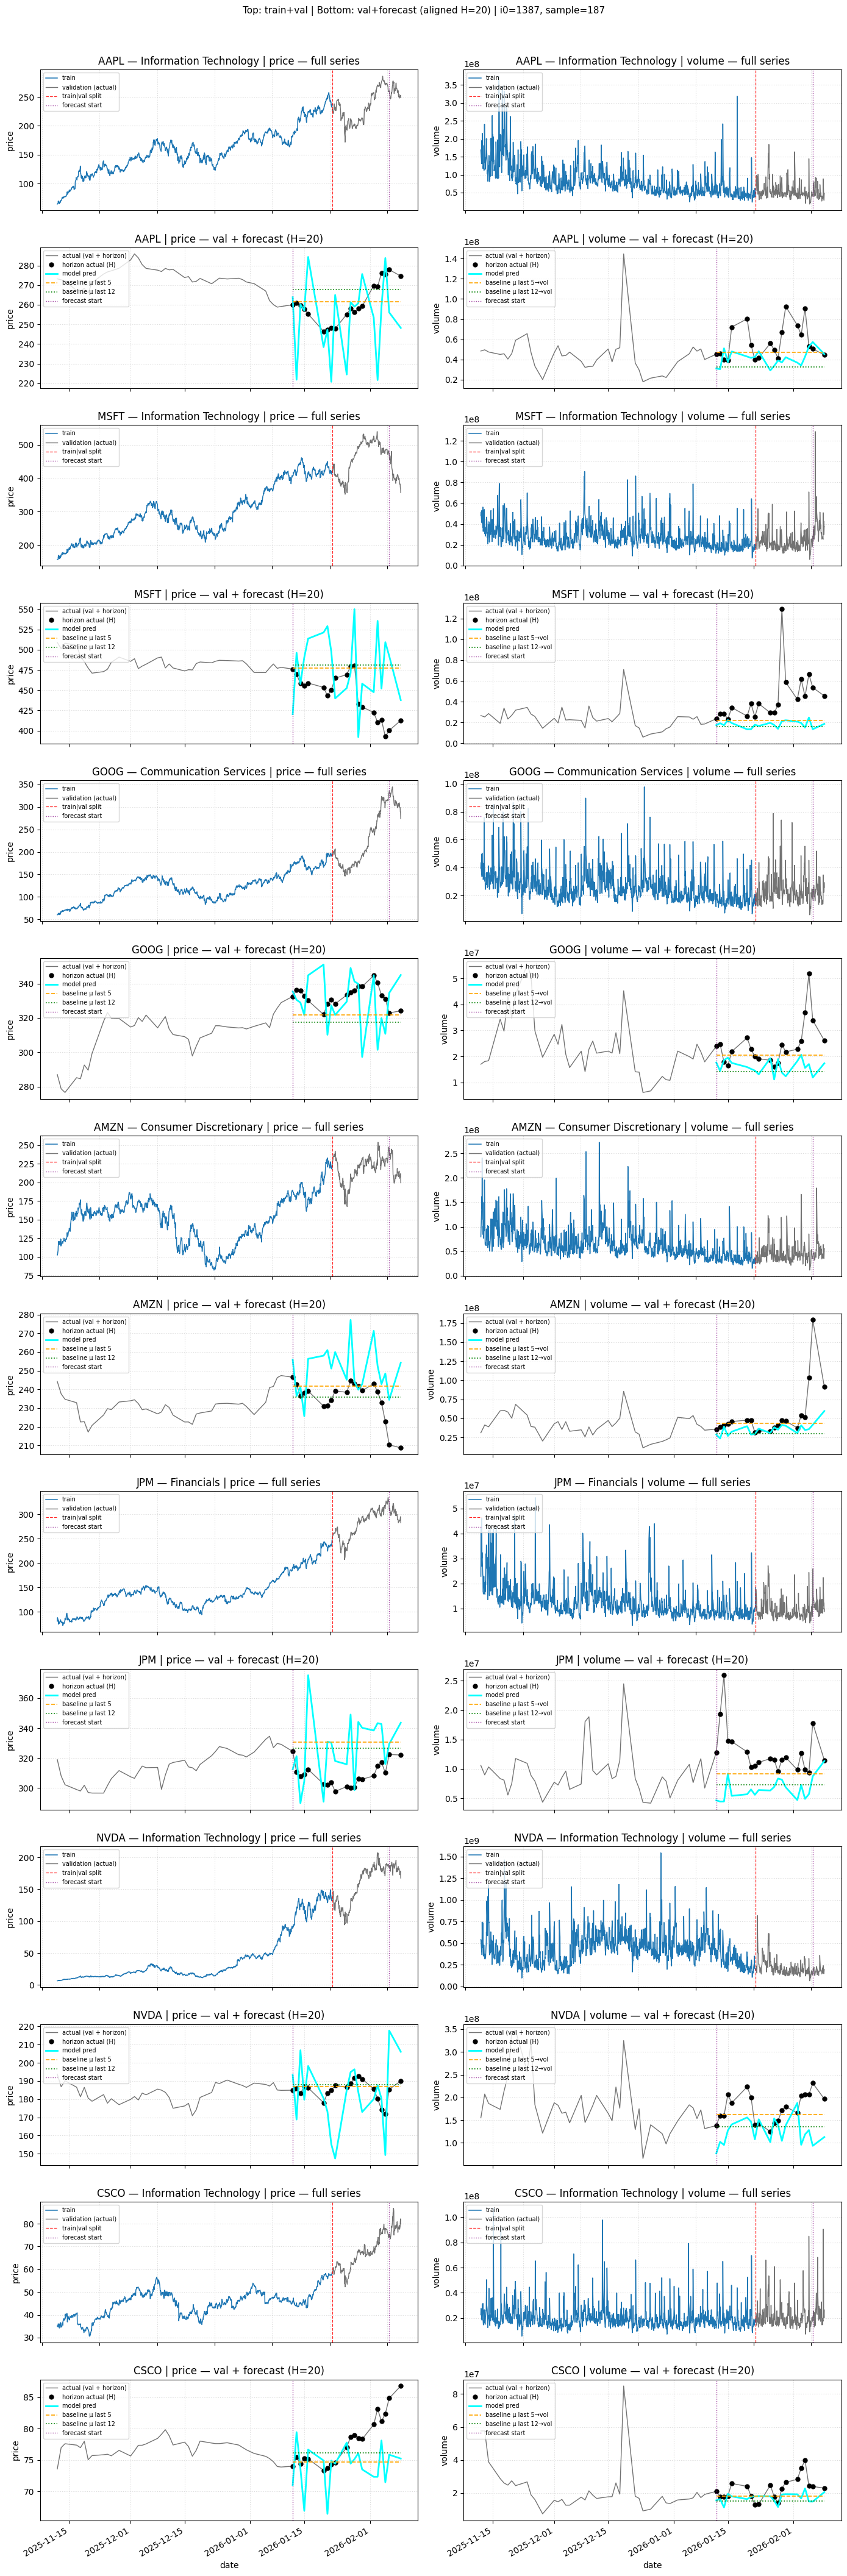

In [10]:
# --- Two rows per ticker × 2 cols (price | volume): top = train+val; bottom = val + forecast (H aligned)


def flat_baseline_last_m(window_prices: np.ndarray, m: int) -> float:
    w = window_prices[-m:] if len(window_prices) >= m else window_prices
    return float(np.mean(w))


def denorm_price(norm_future: np.ndarray, ki: int) -> np.ndarray:
    return norm_future * std_p[ki] + mean_p[ki]


def denorm_logvol(norm_future: np.ndarray, ki: int) -> np.ndarray:
    return norm_future * std_v[ki] + mean_v[ki]


def _style_ts(ax):
    ax.grid(True, linestyle=":", alpha=0.45)
    ax.set_xlabel("date")


rng = np.random.default_rng(0)
idxs = np.arange(len(x_val))
if len(idxs) > n_plot_val:
    idxs = rng.choice(idxs, size=n_plot_val, replace=False)
idxs = sorted(idxs.tolist())

n_pred_h = int(pred["adj_close_path"].shape[2])

for sample_j in idxs:
    i0 = int(i_val[sample_j])
    i_f = i0 + lookback

    P_win = P_raw[i0 : i0 + lookback]
    V_win_raw = np.expm1(V_log1p[i0 : i0 + lookback])

    h_eff = int(
        min(
            n_pred_h,
            horizon,
            max(0, len(dates) - i_f),
            P_raw.shape[0] - i_f,
        )
    )
    if h_eff <= 0:
        continue

    fut_p = P_raw[i_f : i_f + h_eff, :]
    fut_v_raw = np.expm1(V_log1p[i_f : i_f + h_eff, :])
    dh = dates[i_f : i_f + h_eff]

    fig, axes = plt.subplots(2 * k, 2, figsize=(14, 3.0 * 2 * k), sharex=False, squeeze=False)

    for ki, t in enumerate(tickers):
        r_top = 2 * ki
        r_bot = r_top + 1
        ax_pt, ax_vt = axes[r_top, 0], axes[r_top, 1]
        ax_pb, ax_vb = axes[r_bot, 0], axes[r_bot, 1]

        ps = price_panel[t].values.astype(np.float64)
        vs = np.expm1(V_log1p[:, ki])

        # ----- Top row: full train + validation (both price and volume) -----
        for ax, series, yl in ((ax_pt, ps, "price"), (ax_vt, vs, "volume")):
            ax.plot(
                dates[:split_row],
                series[:split_row],
                color="C0",
                lw=1.1,
                label="train",
            )
            ax.plot(
                dates[split_row:],
                series[split_row:],
                color="0.45",
                lw=1.0,
                label="validation (actual)",
            )
            ax.axvline(split_dt, color="red", ls="--", lw=0.9, alpha=0.85, label="train|val split")
            if len(dh) > 0:
                ax.axvline(
                    dh[0],
                    color="purple",
                    ls=":",
                    lw=1.0,
                    alpha=0.75,
                    label="forecast start",
                )
            ax.set_ylabel(yl)
            ax.set_title(f"{t} — {sector_by_ticker[ki]} | {yl} — full series")
            ax.legend(loc="upper left", fontsize=7)
            _style_ts(ax)

        # Predictions (aligned length h_eff)
        ap = norm_p_full[i0 + lookback - 1, ki]
        pred_res = pred["adj_close_path"][sample_j, ki, :h_eff]
        pred_norm = ap + pred_res
        pred_price = denorm_price(pred_norm, ki)
        b5 = flat_baseline_last_m(P_win[:, ki], 5)
        b12 = flat_baseline_last_m(P_win[:, ki], 12)
        act_p_h = fut_p[:, ki].astype(np.float64)

        av = norm_v_full[i0 + lookback - 1, ki]
        pred_vres = pred["volume_path"][sample_j, ki, :h_eff]
        pred_lognorm = av + pred_vres
        pred_log = denorm_logvol(pred_lognorm, ki)
        pred_vol = np.expm1(np.maximum(pred_log, 0))
        b5v = np.expm1(
            flat_baseline_last_m(np.log1p(np.maximum(V_win_raw[:, ki], 0)), 5)
        )
        b12v = np.expm1(
            flat_baseline_last_m(np.log1p(np.maximum(V_win_raw[:, ki], 0)), 12)
        )
        act_v_h = fut_v_raw[:, ki].astype(np.float64)

        assert (
            act_p_h.shape[0] == pred_price.shape[0] == len(dh)
        ), (act_p_h.shape[0], pred_price.shape[0], len(dh))
        assert (
            act_v_h.shape[0] == pred_vol.shape[0] == len(dh)
        ), (act_v_h.shape[0], pred_vol.shape[0], len(dh))

        # ----- Bottom row: validation onward — forecast immediately after val lead-in -----
        idx_lo = max(split_row, i_f - min(lookback, 40))
        idx_hi = min(i_f + h_eff, len(dates))

        # Price bottom
        ax_pb.plot(
            dates[idx_lo:idx_hi],
            ps[idx_lo:idx_hi],
            color="0.35",
            lw=1.0,
            alpha=0.85,
            label="actual (val + horizon)",
        )
        ax_pb.plot(dh, act_p_h, "ko", ms=5, label="horizon actual (H)")
        ax_pb.plot(dh, pred_price, color="cyan", lw=2.0, label="model pred")
        ax_pb.plot([dh[0], dh[-1]], [b5, b5], color="orange", ls="--", lw=1.2, label="baseline μ last 5")
        ax_pb.plot([dh[0], dh[-1]], [b12, b12], color="green", ls=":", lw=1.2, label="baseline μ last 12")
        ax_pb.axvline(dh[0], color="purple", ls=":", lw=1.0, alpha=0.75, label="forecast start")
        ax_pb.set_ylabel("price")
        ax_pb.set_title(f"{t} | price — val + forecast (H={h_eff})")
        ax_pb.legend(loc="upper left", fontsize=7)
        _style_ts(ax_pb)

        # Volume bottom
        ax_vb.plot(
            dates[idx_lo:idx_hi],
            vs[idx_lo:idx_hi],
            color="0.35",
            lw=1.0,
            alpha=0.85,
            label="actual (val + horizon)",
        )
        ax_vb.plot(dh, act_v_h, "ko", ms=5, label="horizon actual (H)")
        ax_vb.plot(dh, pred_vol, color="cyan", lw=2.0, label="model pred")
        ax_vb.plot([dh[0], dh[-1]], [b5v, b5v], color="orange", ls="--", lw=1.2, label="baseline μ last 5→vol")
        ax_vb.plot([dh[0], dh[-1]], [b12v, b12v], color="green", ls=":", lw=1.2, label="baseline μ last 12→vol")
        ax_vb.axvline(dh[0], color="purple", ls=":", lw=1.0, alpha=0.75, label="forecast start")
        ax_vb.set_ylabel("volume")
        ax_vb.set_title(f"{t} | volume — val + forecast (H={h_eff})")
        ax_vb.legend(loc="upper left", fontsize=7)
        _style_ts(ax_vb)

    fig.suptitle(
        f"Top: train+val | Bottom: val+forecast (aligned H={h_eff}) | i0={i0}, sample={sample_j}",
        y=1.005,
        fontsize=11,
    )
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


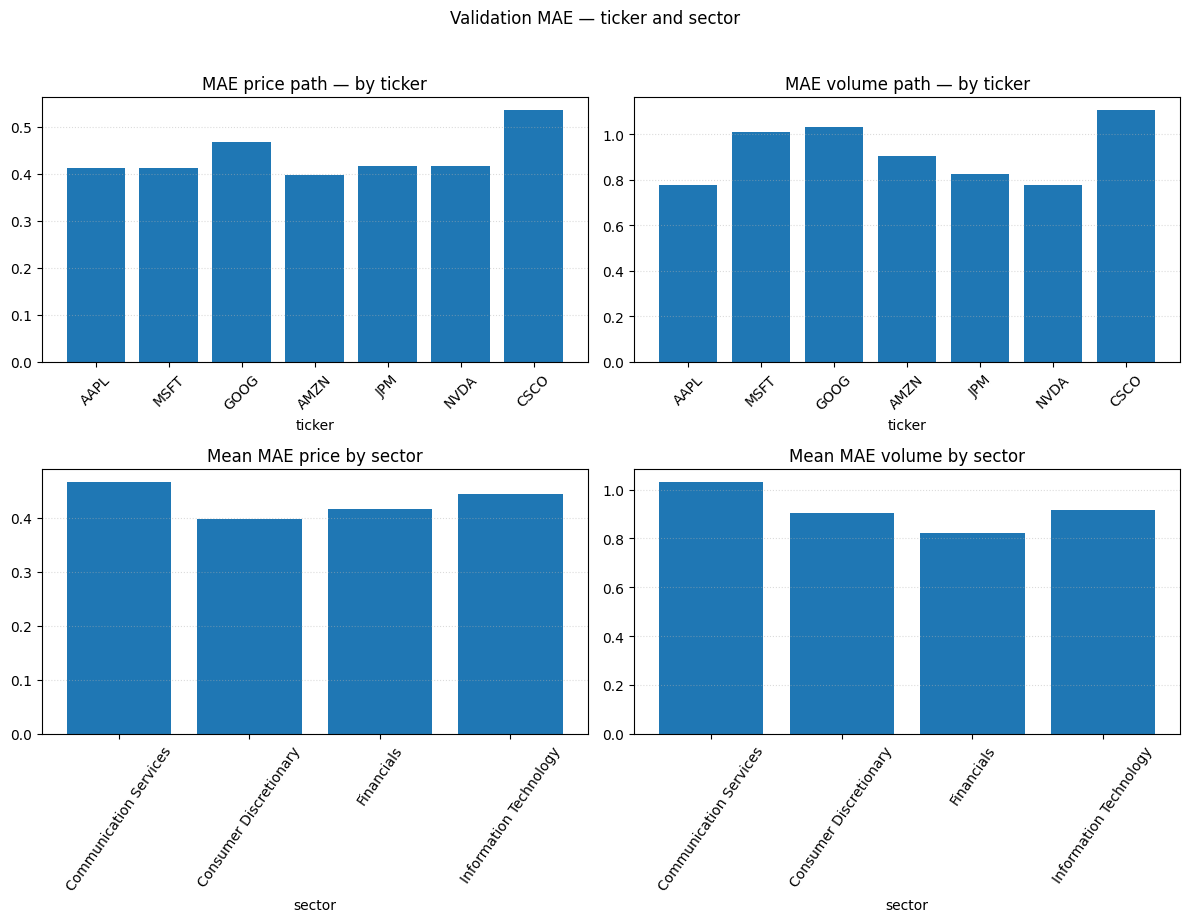

In [11]:
# --- MAE by ticker and sector (2×2 grid, max 2 columns)
err_p = np.abs(pred["adj_close_path"] - y_val["adj_close_path"])
err_v = np.abs(pred["volume_path"] - y_val["volume_path"])
mae_p_t = err_p.mean(axis=(0, 2))
mae_v_t = err_v.mean(axis=(0, 2))

from collections import defaultdict

sec_sum_p = defaultdict(float)
sec_sum_v = defaultdict(float)
sec_cnt = defaultdict(int)
for ki in range(k):
    sec = sector_by_ticker[ki]
    sec_sum_p[sec] += mae_p_t[ki]
    sec_sum_v[sec] += mae_v_t[ki]
    sec_cnt[sec] += 1
sectors_u = sorted(sec_cnt.keys())
mae_p_sec = [sec_sum_p[s] / sec_cnt[s] for s in sectors_u]
mae_v_sec = [sec_sum_v[s] / sec_cnt[s] for s in sectors_u]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
xpos = np.arange(k)

axes[0, 0].bar(xpos, mae_p_t)
axes[0, 0].set_xticks(xpos, tickers)
axes[0, 0].set_title("MAE price path — by ticker")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].set_xlabel("ticker")
axes[0, 0].grid(True, axis="y", linestyle=":", alpha=0.45)

axes[0, 1].bar(xpos, mae_v_t)
axes[0, 1].set_xticks(xpos, tickers)
axes[0, 1].set_title("MAE volume path — by ticker")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].set_xlabel("ticker")
axes[0, 1].grid(True, axis="y", linestyle=":", alpha=0.45)

sx = np.arange(len(sectors_u))
axes[1, 0].bar(sx, mae_p_sec)
axes[1, 0].set_xticks(sx, sectors_u)
axes[1, 0].set_title("Mean MAE price by sector")
axes[1, 0].tick_params(axis="x", rotation=55)
axes[1, 0].set_xlabel("sector")
axes[1, 0].grid(True, axis="y", linestyle=":", alpha=0.45)

axes[1, 1].bar(sx, mae_v_sec)
axes[1, 1].set_xticks(sx, sectors_u)
axes[1, 1].set_title("Mean MAE volume by sector")
axes[1, 1].tick_params(axis="x", rotation=55)
axes[1, 1].set_xlabel("sector")
axes[1, 1].grid(True, axis="y", linestyle=":", alpha=0.45)

plt.suptitle("Validation MAE — ticker and sector", y=1.02)
plt.tight_layout()
plt.show()


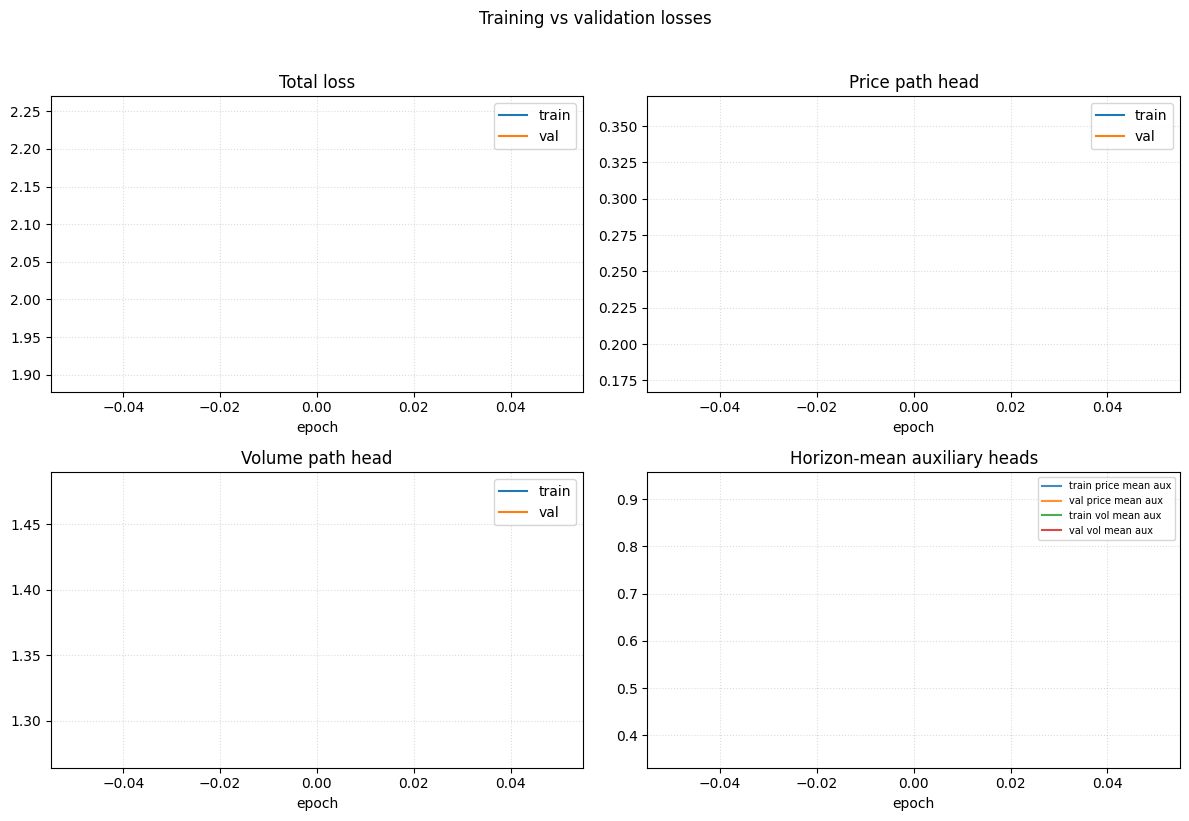

In [12]:
# --- Training / validation loss (2×2 grid; dotted grid on line plots)
h = history.history
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(h["loss"], label="train")
axes[0, 0].plot(h["val_loss"], label="val")
axes[0, 0].set_title("Total loss")
axes[0, 0].legend()
axes[0, 0].set_xlabel("epoch")
axes[0, 0].grid(True, linestyle=":", alpha=0.45)

pairs = [
    ("adj_close_path_loss", "Price path head"),
    ("volume_path_loss", "Volume path head"),
]
for ax, (name, title) in zip([axes[0, 1], axes[1, 0]], pairs):
    kt, kv = name, "val_" + name
    if kt in h:
        ax.plot(h[kt], label="train")
    if kv in h:
        ax.plot(h[kv], label="val")
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel("epoch")
    ax.grid(True, linestyle=":", alpha=0.45)

ax = axes[1, 1]
for lbl, kt, kv in [
    ("price mean aux", "horizon_mean_residual_loss", "val_horizon_mean_residual_loss"),
    ("vol mean aux", "horizon_mean_residual_vol_loss", "val_horizon_mean_residual_vol_loss"),
]:
    if kt in h:
        ax.plot(h[kt], label="train " + lbl, alpha=0.85)
    if kv in h:
        ax.plot(h[kv], label="val " + lbl, alpha=0.85)
ax.set_title("Horizon-mean auxiliary heads")
ax.legend(fontsize=7)
ax.set_xlabel("epoch")
ax.grid(True, linestyle=":", alpha=0.45)

plt.suptitle("Training vs validation losses", y=1.02)
plt.tight_layout()
plt.show()
